In [1]:
%load_ext autoreload
%autoreload 2

import os
import argparse
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
import utils.stats_utils as stats_utils
from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import *
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io
from scripts.pseudo_decoding.belief_partitions.decode_pref_on_choice_axis import get_proj_mode

plt.rcParams.update({"font.size": 16})

# Preference decoding vs. preference projected onto the choice axis

Preference decoding asks how separable **High X** vs. **High Not X** activity is, in trials where
feature X was chosen and correct. Here we compare it against the separability of those same two
conditions once projected onto the **choice axis** (Chose X vs. Not Chose X, fit on all units),
where the axis direction is fixed and only a threshold along it is refit.

| series | mode | path |
| --- | --- | --- |
| preference | `pref` | `/data/patrick_res/belief_partitions` |
| on choice axis | `pref_on_choice_Response_Correct` | `/data/patrick_res/choice_axis_projection_accs` |

The choice axis is taken from the choice runs fit on **correct trials only**
(`choice_reward/both_{event}[_{region}]_Response_Correct`), which is the better matched axis, since
the preference trials being projected are themselves `Response Correct` + `Choice Chose`. Set
`AXIS_BEH_FILTERS = {}` in the config cell below to read the earlier all-trials axis instead
(mode `pref_on_choice`) — those results are retained on disk, so both versions are reproducible
from this notebook.

The projection is computed by
`scripts/pseudo_decoding/belief_partitions/decode_pref_on_choice_axis.py`, reusing the preference
run's units (`pref_99th_window_filter_drift`), trials (`Response Correct`, `Choice Chose`),
train/test splits and pseudo population generation, so the two are directly comparable. Each is
shown alongside its own session-permute shuffle.

Below the traces, each series gets its own row of significance bars in its own color: preference
on top (blue), the projection beneath it (purple). Both are the one-sided permutation test of that
series against its own shuffle at each timepoint, thicker bars for smaller p (p < 0.05 / 0.01 /
0.001, `visualization_utils.SIG_LEVELS`). Note this asks whether each series beats its own
shuffle, not whether they differ from each other.

Whole population plus the 6 regions of interest, for both StimOnset and FeedbackOnsetLong. The
second half of the notebook draws the same accuracies stacked instead of overlaid, one row per
decoder, with the choice decoding the axis comes from added as a third row.

In [3]:
# Trials the choice axis was fit on, picking which set of runs the whole notebook reads:
#   {}                        -> the original all-trials choice axis, mode pref_on_choice
#   {"Response": "Correct"}   -> the correct-only choice re-runs, mode pref_on_choice_Response_Correct
#   {"Response": "Correct", "BeliefPartition": "High Not X"} -> the A-vs-B stimulus axis of the A/B/C design, mode pref_on_choice_Response_Correct_BeliefPartition_High_Not_X
# Both are on disk, so flipping this back reproduces the earlier figures. It selects the choice
# row's runs too, so row 1 of the stacked figure is always the axis row 3 is projected onto.
AXIS_BEH_FILTERS = {"Response": "Correct", "BeliefPartition": "High Not X"}
PROJ_MODE = get_proj_mode(AXIS_BEH_FILTERS)

MODE_TO_BASE_PATH = {
    "pref": "/data/patrick_res/belief_partitions",
    PROJ_MODE: "/data/patrick_res/choice_axis_projection_accs",
    # choice decoding fit on all units, the runs decode_pref_on_choice_axis.py takes its axis from
    "choice": "/data/patrick_res/choice_reward",
}

# modes drawn in one set of axes, preference against its projection
OVERLAY_MODES = ["pref", PROJ_MODE]
# one mode per row of the stacked figure, top to bottom
ROW_MODES = ["choice", "pref", PROJ_MODE]

SERIES_NAMES = {
    "pref": "preference",
    "pref_shuffle": "preference shuffle",
    PROJ_MODE: "on choice axis",
    f"{PROJ_MODE}_shuffle": "on choice axis shuffle",
    "choice": "choice",
    "choice_shuffle": "choice shuffle",
}
SERIES_ORDER = ["preference", "preference shuffle", "on choice axis", "on choice axis shuffle"]
SERIES_TO_COLOR = {
    "preference": "tab:blue",
    "preference shuffle": "#aec7e8",
    "on choice axis": "tab:purple",
    "on choice axis shuffle": "#c5b0d5",
    "choice": "tab:orange",
    "choice shuffle": "#ffbb78",
}
# series that get a row of significance bars, drawn top to bottom in this order
SIG_BAR_SERIES = ["preference", "on choice axis"]

# whole population, then the 6 regions of interest
POPULATIONS = [(None, None, "whole population")] + [
    ("structure_level2_cleaned", region, region) for region in REGIONS_OF_INTEREST
]


def get_args(mode, region_level, regions, trial_event):
    """
    Configs for one mode's run: the trials and units it ran on, and the path it's stored under
    """
    args = argparse.Namespace(**BeliefPartitionConfigs()._asdict())
    args.subject = "both"
    args.mode = mode
    if mode == "choice":
        # the all units choice runs use no subpopulation, and only the trials AXIS_BEH_FILTERS
        # names -- matching what decode_pref_on_choice_axis.load_choice_axes reads for the same
        # filters, see slurm_launch_choice_all_units.sh
        args.beh_filters = AXIS_BEH_FILTERS
        args.sig_unit_level = None
    else:
        args.beh_filters = {"Response": "Correct", "Choice": "Chose"}
        args.sig_unit_level = "pref_99th_window_filter_drift"
    args.region_level = region_level
    args.regions = regions
    args.trial_event = trial_event
    args.base_output_path = MODE_TO_BASE_PATH[mode]
    return args


def read_modes(region_level, regions, trial_event, modes=OVERLAY_MODES):
    """
    Reads each mode's accuracies, with their shuffles, into one frame
    """
    res = []
    for mode in modes:
        args = get_args(mode, region_level, regions, trial_event)
        res.append(belief_partitions_io.read_results(args, FEATURES))
    res = pd.concat(res)
    res["series"] = res["mode"].map(SERIES_NAMES)
    res["trial_event"] = trial_event
    return res


CHOICE_PVALS = {}


def get_choice_pvals(region_level, regions, trial_event, res=None):
    """
    Choice's per-timepoint p value against its own shuffle, computed here and cached.

    The all-unit choice runs have no p values on disk: compute_p_vals_for_decoders.py only covers
    the choice_99th_window_filter_drift subpop, whose dirs are the *_units ones. This is the same
    one-sided permutation test it would have written, run over the results already in memory.
    """
    key = (regions, trial_event)
    if key not in CHOICE_PVALS:
        args = get_args("choice", region_level, regions, trial_event)
        if res is None:
            res = belief_partitions_io.read_results(args, FEATURES)
        else:
            res = res[res["mode"].isin(["choice", "choice_shuffle"])].copy()
        CHOICE_PVALS[key] = stats_utils.compute_p_for_decoding_by_time(res, args)
    return CHOICE_PVALS[key]


def read_pvals(region_level, regions, trial_event, modes=OVERLAY_MODES, res=None):
    """
    Reads each mode's per-timepoint p value against its own shuffle, keyed by series name.
    All are the same one-sided permutation test (stats_utils.compute_p_for_decoding_by_time),
    written by p_val_computations/compute_p_vals_for_decoders.py for preference and
    p_val_computations/compute_p_vals_for_pref_on_choice.py for the projection, computed on the
    fly for choice. `res` lets choice reuse an already read frame.
    """
    p_vals = {}
    for mode in modes:
        if mode == "choice":
            p_vals[SERIES_NAMES[mode]] = get_choice_pvals(region_level, regions, trial_event, res)
            continue
        args = get_args(mode, region_level, regions, trial_event)
        dir = belief_partitions_io.get_dir_name(args, make_dir=False)
        p_vals[SERIES_NAMES[mode]] = pd.read_pickle(os.path.join(dir, f"{mode}_pvals.pickle"))
    return p_vals

In [4]:
def format_event_axis(ax, trial_event, with_xlabel=True):
    """
    Event markers, ticks and x label for one trial event's column of axes
    """
    ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)
    if trial_event == "StimOnset":
        ax.axvline(-.5, color="grey", linestyle="dotted", linewidth=3)
        ticks = [-1, -.5, 0, .5, 1]
        label = "Time to stimuli appear (s)"
    else:
        ax.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
        ticks = [-1.5, -1, -.5, 0, .5, 1, 1.5]
        label = "Time to feedback (s)"
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks)
    ax.set_xlabel(label if with_xlabel else None)


def plot_pref_vs_choice_axis(region_level, regions, title=None):
    """
    Both trial events side by side, in the style of visualization_utils.plot_combined_accs
    """
    stim_res = read_modes(region_level, regions, "StimOnset")
    fb_res = read_modes(region_level, regions, "FeedbackOnsetLong")

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 3.5), sharey="row",
        width_ratios=[stim_res.Time.nunique(), fb_res.Time.nunique()]
    )
    for ax, res in ((ax1, stim_res), (ax2, fb_res)):
        sns.lineplot(
            res, x="Time", y="Accuracy", hue="series", hue_order=SERIES_ORDER,
            palette=SERIES_TO_COLOR, linewidth=3, ax=ax, errorbar="se"
        )
        ax.axhline(y=0.5, linestyle="dotted", color="black")

    # significance vs. each series' own shuffle, a row of bars per series below the traces,
    # colored to match the trace. Spacing is a fraction of the y range, so the rows stay
    # clear of each other whatever the accuracies are: at this figure height it leaves a
    # visible gap between even the thickest (p < 0.001) bars. Read the shared limits first,
    # before any bar has a chance to rescale the axes.
    bottom, top = ax1.get_ylim()
    spacing = 0.08 * (top - bottom)
    for ax, trial_event in ((ax1, "StimOnset"), (ax2, "FeedbackOnsetLong")):
        p_vals = read_pvals(region_level, regions, trial_event)
        for i, series in enumerate(SIG_BAR_SERIES):
            visualization_utils.plot_sig_bars(
                p_vals[series], bottom - (i + 1) * spacing, ax, color=SERIES_TO_COLOR[series]
            )
    # shared y, so these set both: make room for the bars without rescaling the traces, and
    # keep the ticks on the traces, since an accuracy tick in the bar strip reads as data
    ax1.set_ylim(bottom - (len(SIG_BAR_SERIES) + 0.5) * spacing, top)
    ax1.set_yticks([tick for tick in ax1.get_yticks() if bottom <= tick <= top])

    format_event_axis(ax1, "StimOnset")
    ax1.set_ylabel("Accuracy")
    format_event_axis(ax2, "FeedbackOnsetLong")

    visualization_utils.format_plot([ax1, ax2])
    ax1.get_legend().remove()
    legend = ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    for line in legend.get_lines():
        line.set_linewidth(6)
    if title:
        ax1.set_title(title, loc="left")
    fig.tight_layout()
    return fig, (ax1, ax2), pd.concat((stim_res, fb_res))

## Whole population

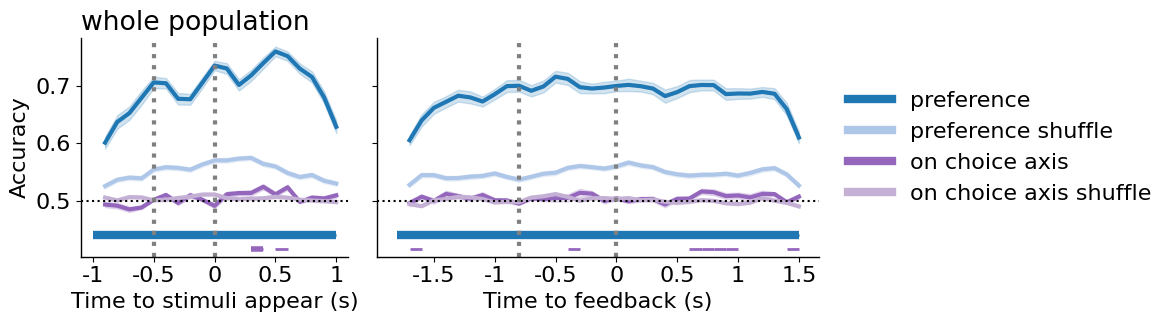

In [5]:
fig, _, whole_pop_res = plot_pref_vs_choice_axis(None, None, title="whole population")

## Regions of interest

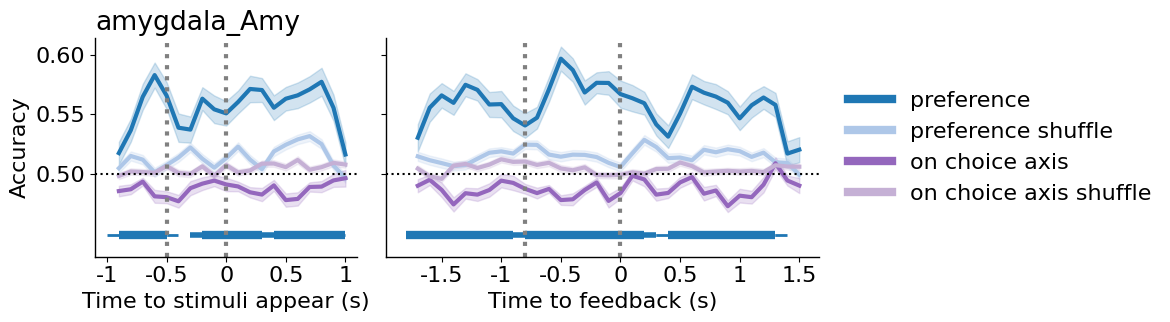

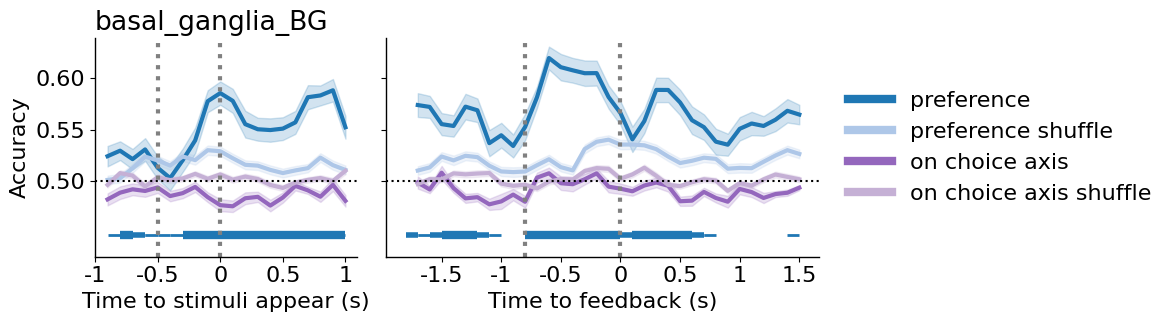

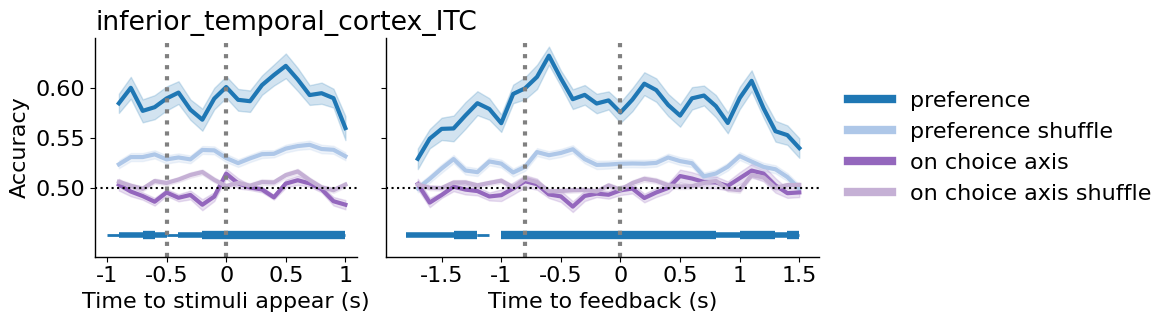

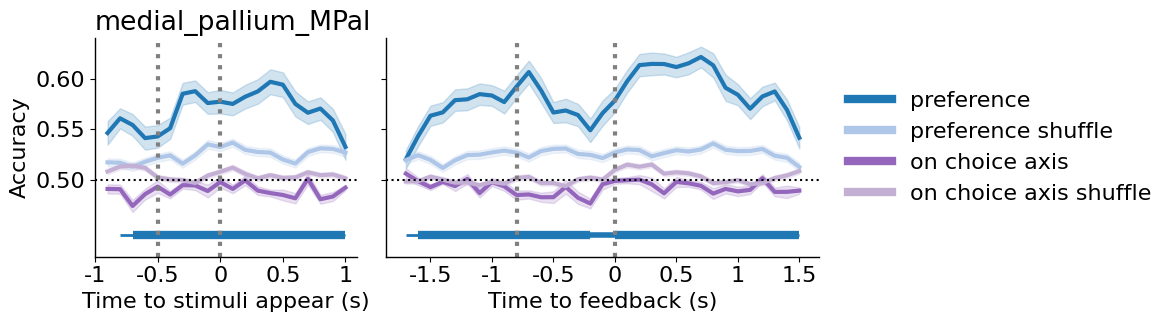

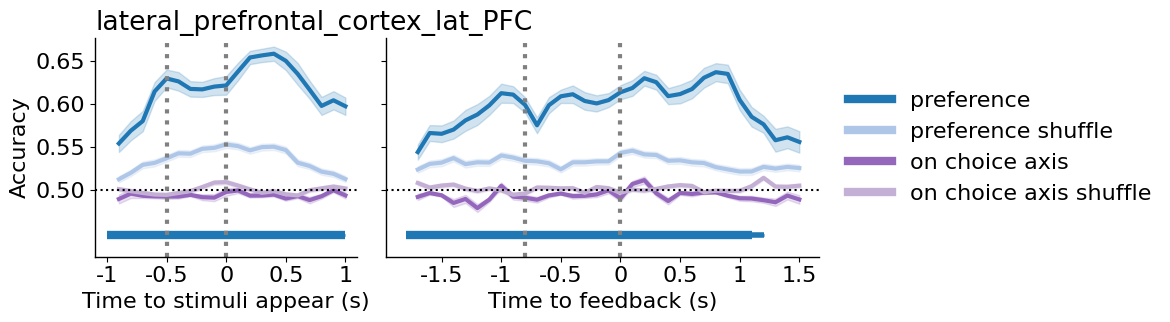

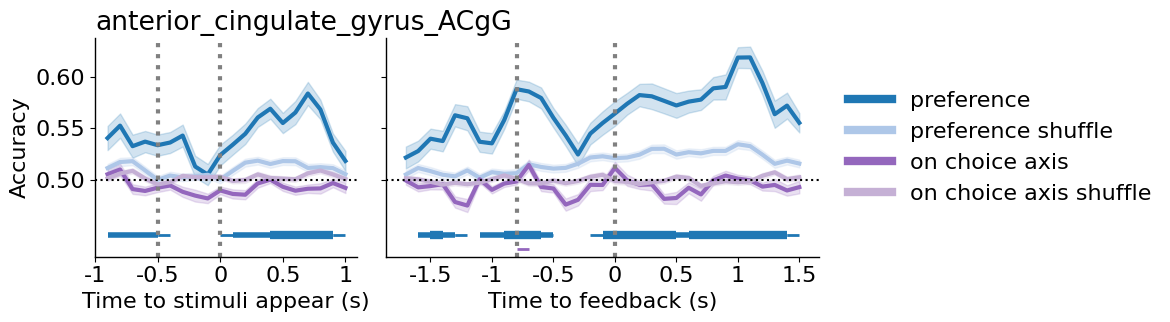

In [6]:
all_res = [whole_pop_res.assign(population="whole population")]
for region_level, regions, name in POPULATIONS[1:]:
    _, _, res = plot_pref_vs_choice_axis(region_level, regions, title=name)
    all_res.append(res.assign(population=name))
all_res = pd.concat(all_res)

# One row per decoder: choice, preference, preference on the choice axis

The same accuracies again, but stacked instead of overlaid, with the choice decoding the axis
itself comes from added on top:

| row | mode | trials, units | path |
| --- | --- | --- | --- |
| choice | `choice` | `Response Correct`, all units | `/data/patrick_res/choice_reward/both_{event}[_{region}]_Response_Correct` |
| preference | `pref` | `Response Correct`, `Choice Chose`, `pref_99th_window_filter_drift` | `/data/patrick_res/belief_partitions` |
| on choice axis | `pref_on_choice_Response_Correct` | same as preference | `/data/patrick_res/choice_axis_projection_accs` |

Row 1 is Chose X vs. Not Chose X fit on the full population — the runs
`decode_pref_on_choice_axis.load_choice_axes` reads its axis from, so row 3 is row 2's conditions
read out along row 1's axis. Row 1 follows `AXIS_BEH_FILTERS`, so it is always the same choice run
the axis in row 3 came from. Rows 1 and 2 are decoders fit to their own conditions; only row 3 has
a fixed direction. Note rows 1 and 2 are not on the same trials or units, so the comparison of
interest is each row against its own shuffle, not row 1's height against row 2's.

Each panel shows one series against its own session-permute shuffle, with one row of significance
bars beneath (same one-sided permutation test as above). All six panels share a y axis, so
accuracy heights are directly comparable across rows. Choice has no `*_pvals.pickle` on disk for
these all-unit runs, so its p values are computed in `get_choice_pvals` above.

In [7]:
def plot_stacked_accs(region_level, regions, title=None):
    """
    One row per mode rather than overlaying them: choice on top, preference, then preference
    projected onto the choice axis. Columns are the two trial events, every panel shares a y
    axis so the rows can be read against each other.
    """
    trial_events = ["StimOnset", "FeedbackOnsetLong"]
    res = {
        trial_event: read_modes(region_level, regions, trial_event, modes=ROW_MODES)
        for trial_event in trial_events
    }

    fig, axs = plt.subplots(
        len(ROW_MODES), len(trial_events), figsize=(12, 3 * len(ROW_MODES)),
        sharey=True, sharex="col",
        width_ratios=[res[trial_event].Time.nunique() for trial_event in trial_events]
    )
    for row, mode in enumerate(ROW_MODES):
        # the mode's own trace and its shuffle, nothing else in the panel
        series = [SERIES_NAMES[mode], SERIES_NAMES[f"{mode}_shuffle"]]
        for col, trial_event in enumerate(trial_events):
            ax = axs[row, col]
            sns.lineplot(
                res[trial_event][res[trial_event].series.isin(series)],
                x="Time", y="Accuracy", hue="series", hue_order=series,
                palette=SERIES_TO_COLOR, linewidth=3, ax=ax, errorbar="se"
            )
            ax.axhline(y=0.5, linestyle="dotted", color="black")
            format_event_axis(ax, trial_event, with_xlabel=row == len(ROW_MODES) - 1)

    # one row of significance bars per panel, that mode against its own shuffle, colored to
    # match the trace. Read the shared limits before any bar can rescale the axes.
    bottom, top = axs[0, 0].get_ylim()
    spacing = 0.08 * (top - bottom)
    for row, mode in enumerate(ROW_MODES):
        for col, trial_event in enumerate(trial_events):
            p_vals = read_pvals(
                region_level, regions, trial_event, modes=[mode], res=res[trial_event]
            )
            visualization_utils.plot_sig_bars(
                p_vals[SERIES_NAMES[mode]], bottom - spacing, axs[row, col],
                color=SERIES_TO_COLOR[SERIES_NAMES[mode]]
            )
    # shared y, so these set every panel: room for the bars without rescaling the traces, and
    # ticks kept on the traces, since an accuracy tick in the bar strip reads as data
    axs[0, 0].set_ylim(bottom - 1.5 * spacing, top)
    axs[0, 0].set_yticks([tick for tick in axs[0, 0].get_yticks() if bottom <= tick <= top])

    visualization_utils.format_plot(axs)
    for row in range(len(ROW_MODES)):
        axs[row, 0].set_ylabel("Accuracy")
        axs[row, 1].set_ylabel(None)
        axs[row, 0].get_legend().remove()
        # per row, since each row names its own pair of series
        legend = axs[row, 1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
        for line in legend.get_lines():
            line.set_linewidth(6)
    if title:
        axs[0, 0].set_title(title, loc="left")
    fig.tight_layout()
    return fig, axs, pd.concat(res.values())

## Whole population, stacked

100%|██████████| 33/33 [00:00<00:00, 44.08it/s]


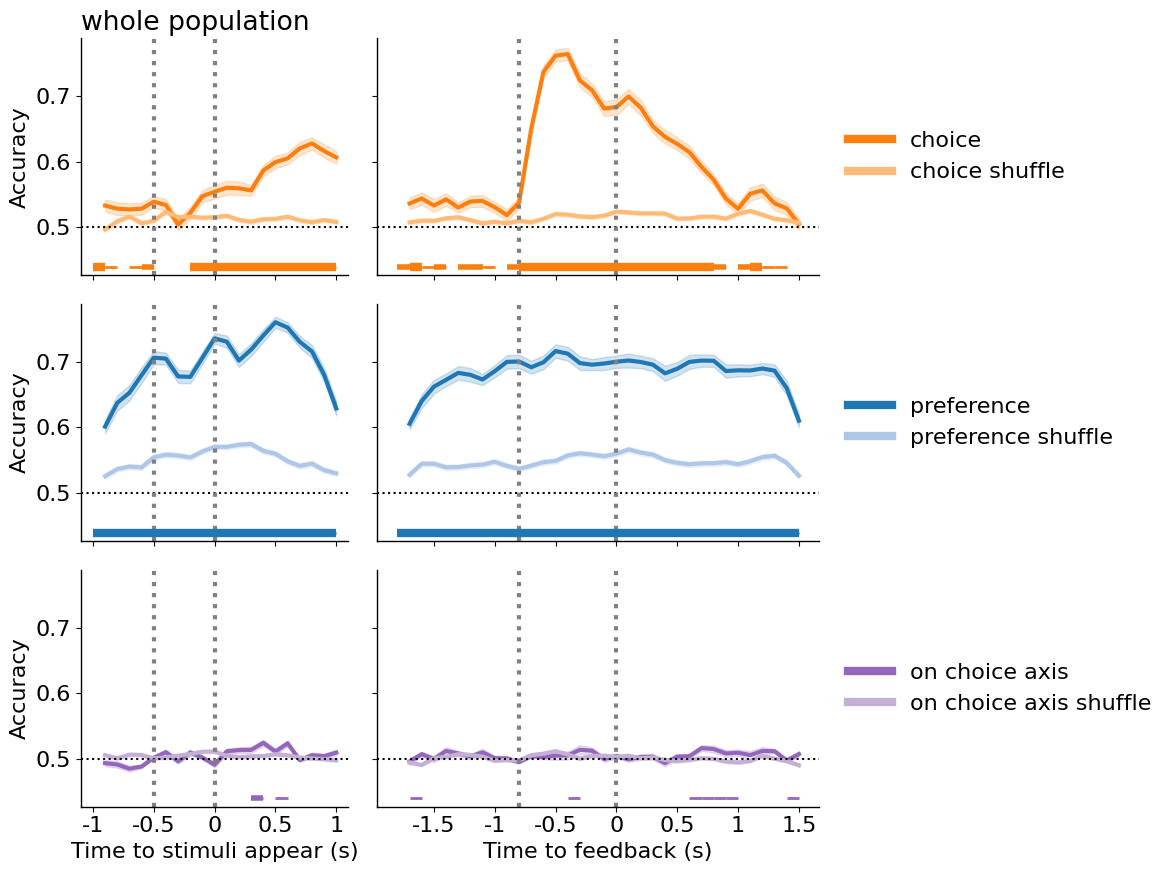

In [8]:
fig, _, whole_pop_stacked_res = plot_stacked_accs(None, None, title="whole population")

## Regions of interest, stacked

100%|██████████| 33/33 [00:00<00:00, 43.99it/s]


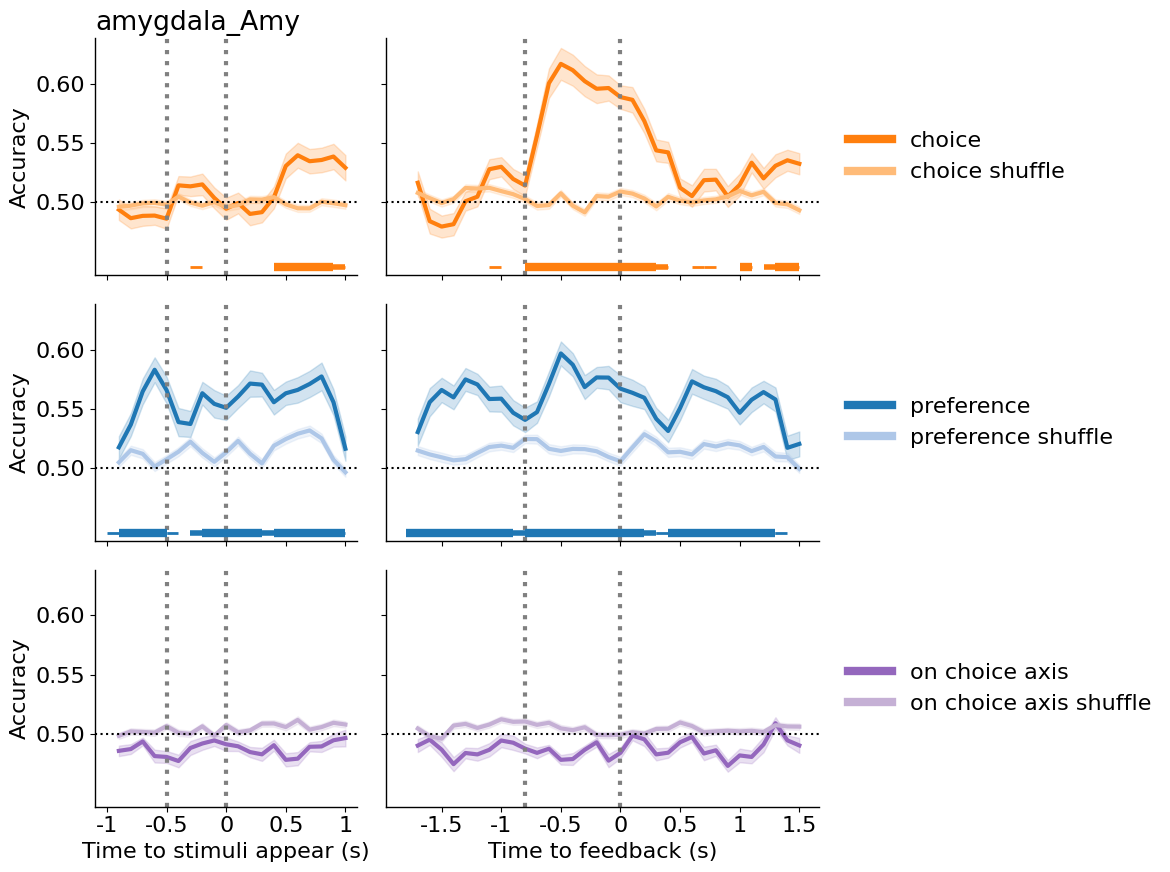

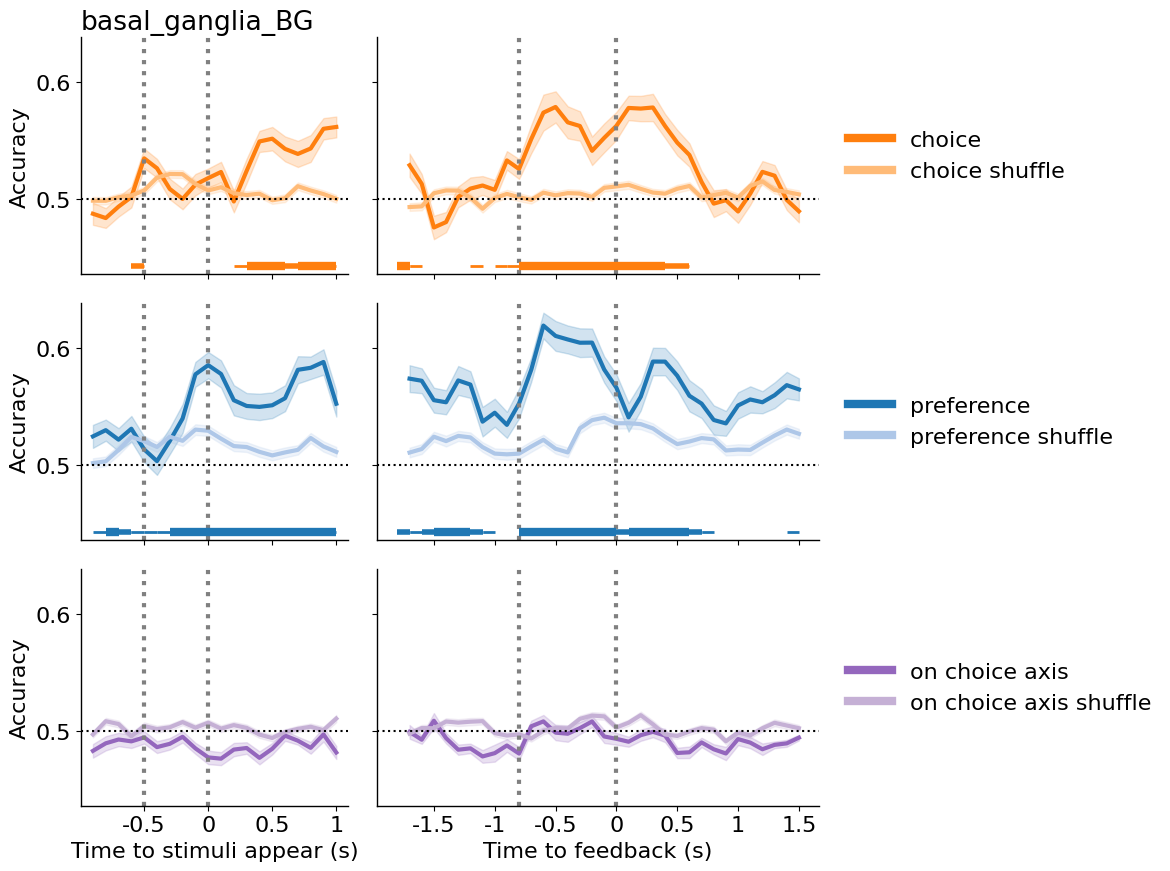

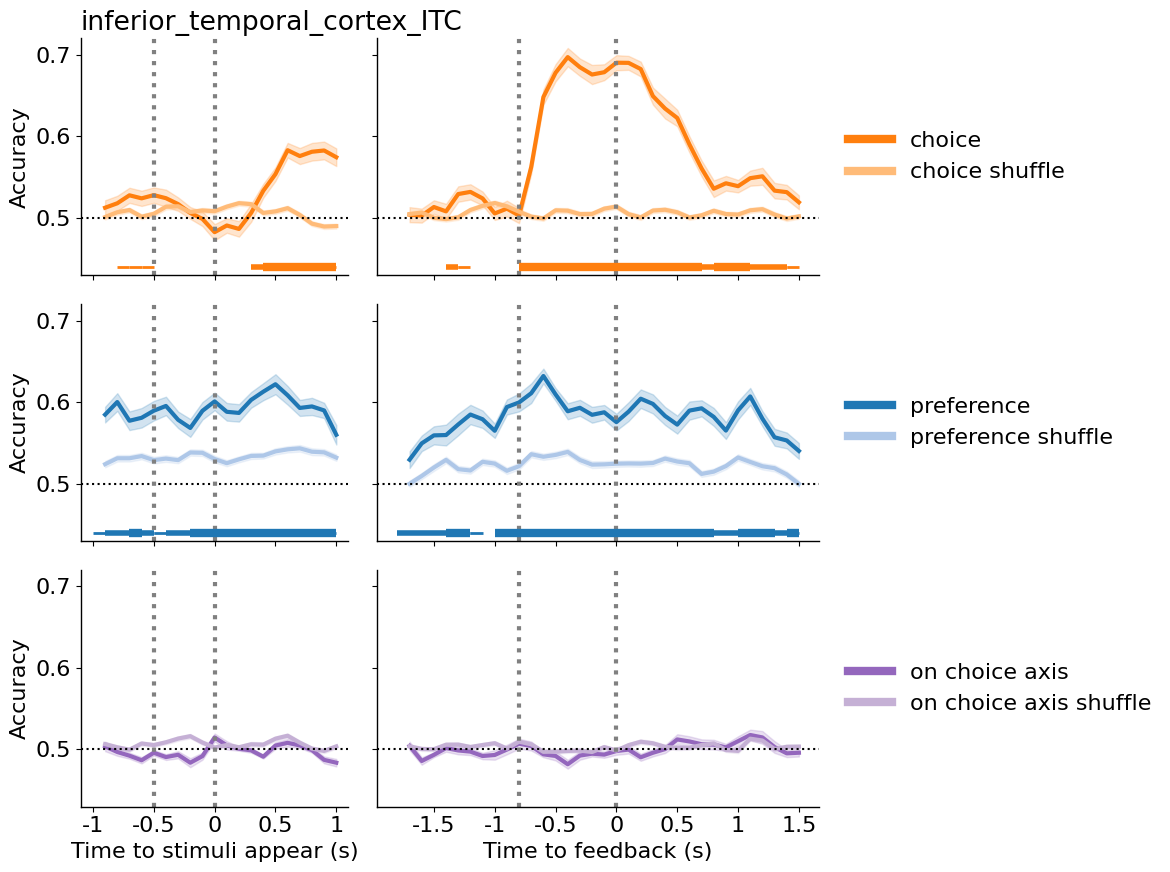

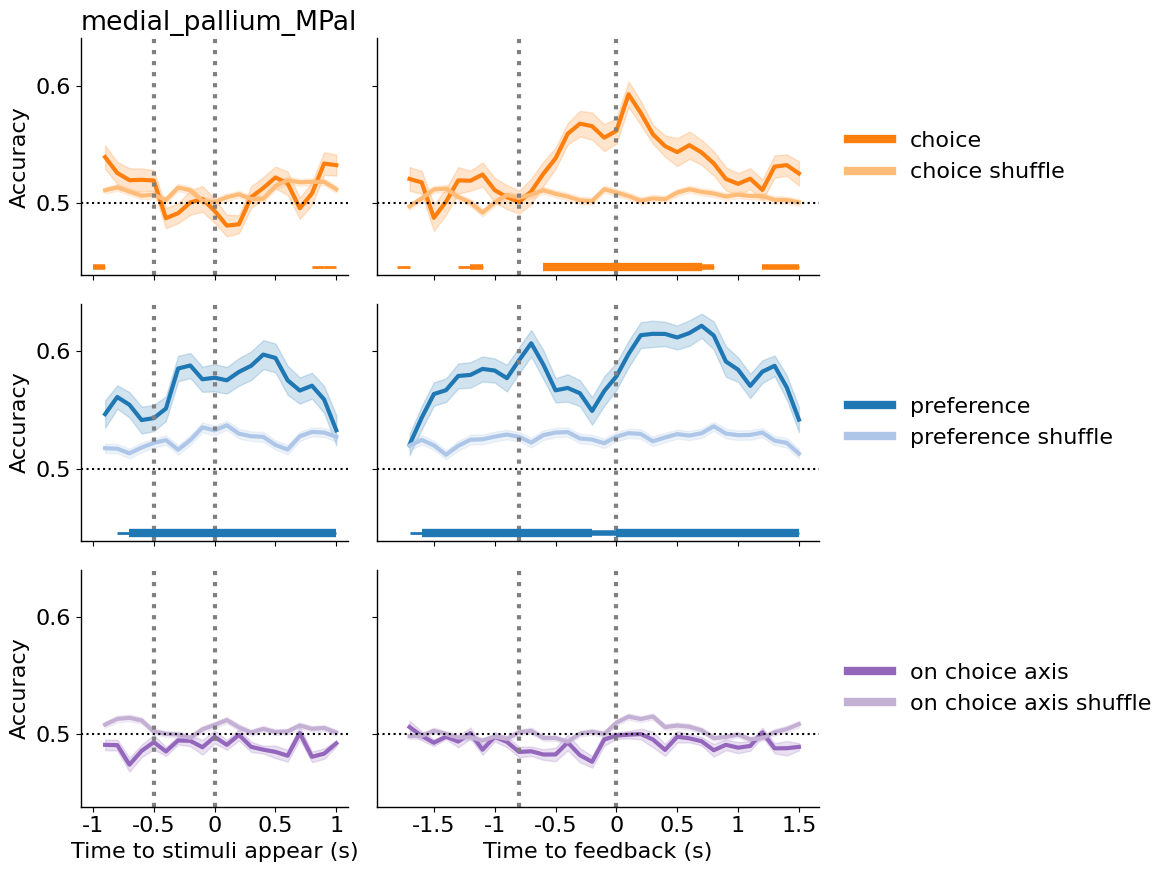

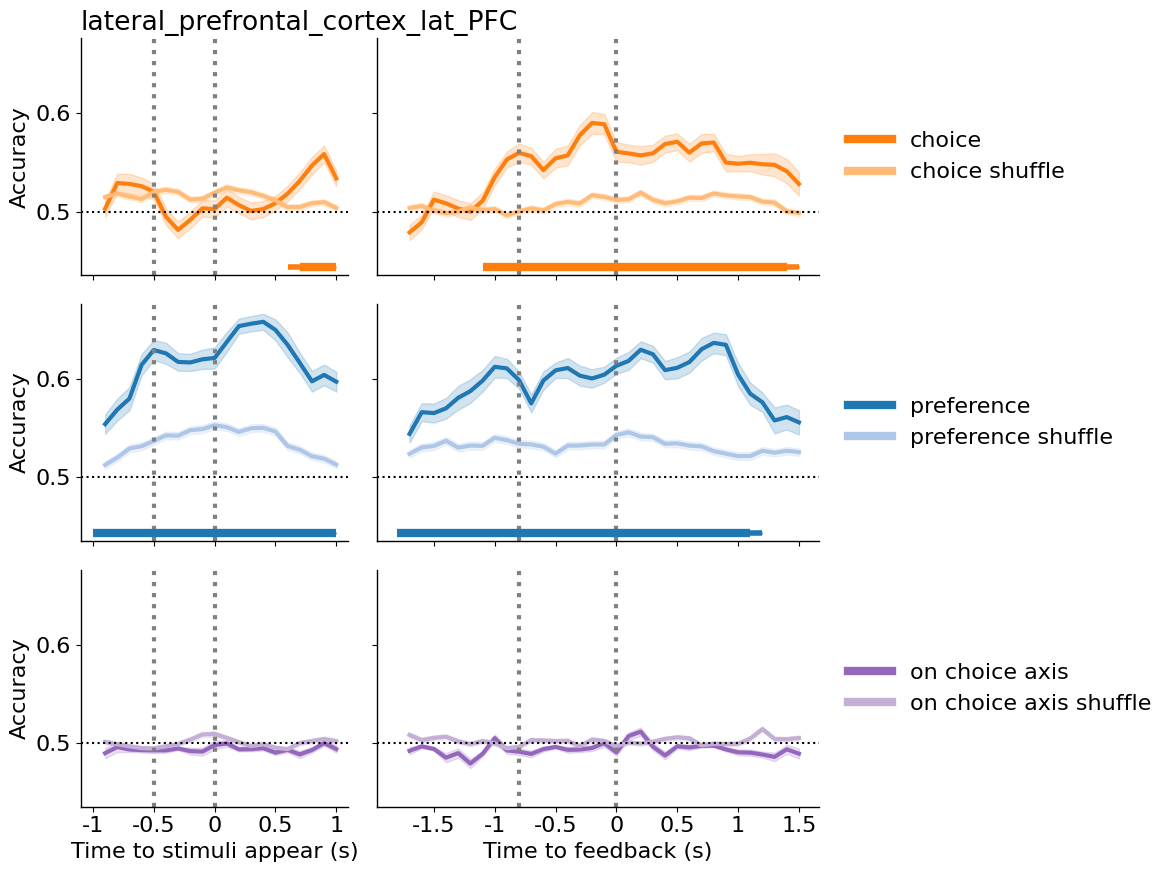

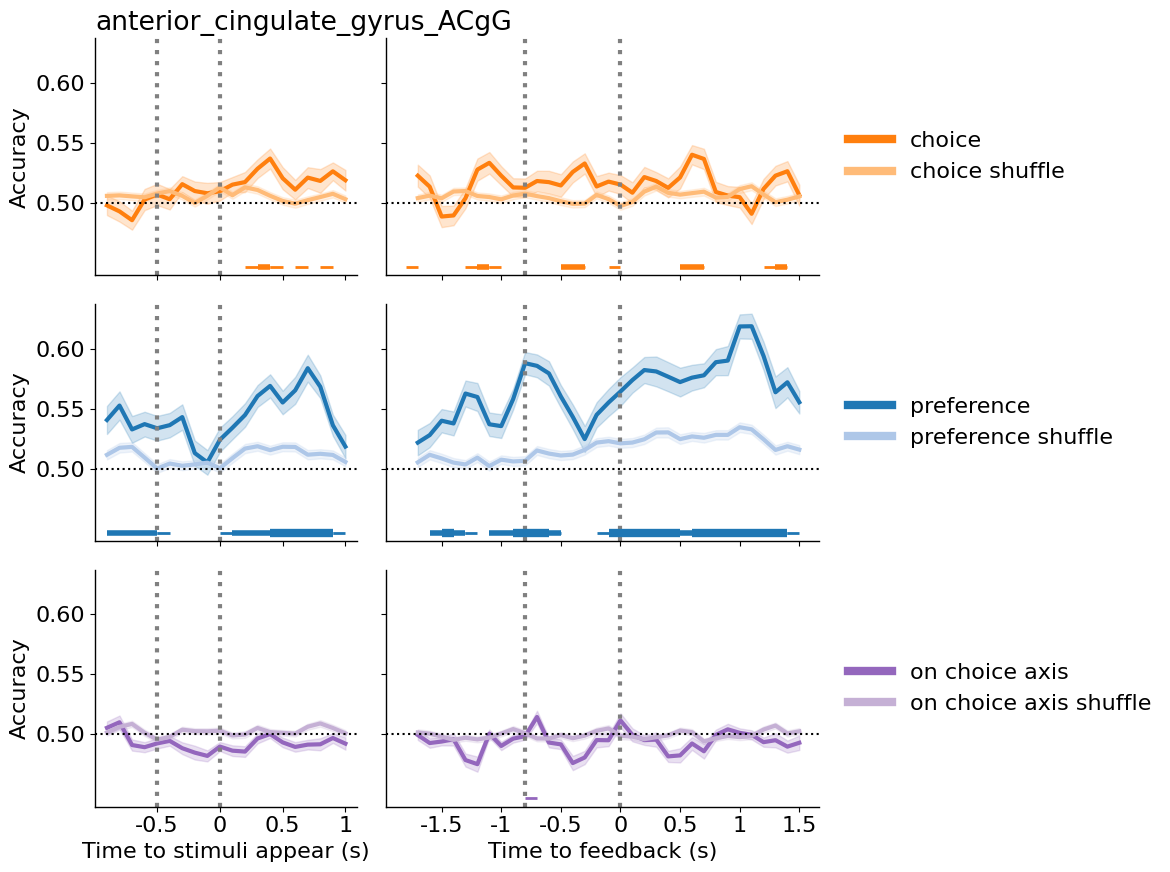

In [9]:
all_stacked_res = [whole_pop_stacked_res.assign(population="whole population")]
for region_level, regions, name in POPULATIONS[1:]:
    _, _, res = plot_stacked_accs(region_level, regions, title=name)
    all_stacked_res.append(res.assign(population=name))
all_stacked_res = pd.concat(all_stacked_res)

## Summary

Mean accuracy over all time bins, features and runs, alongside each series' distance above its own
shuffle. `frac` is how much of preference's separation over its own shuffle is recovered on the
choice axis. `choice gap` is the same distance for the all-unit choice decoding the axis comes
from, on its own trials and units, so it is context for how strong that axis is rather than
something preference is measured against.

In [9]:
def mean_by_series(res):
    return res.groupby(["population", "trial_event", "series"]).Accuracy.mean().unstack("series")


summary = mean_by_series(all_res)
# choice only comes with the stacked read, it isn't one of the overlaid series
summary[["choice", "choice shuffle"]] = mean_by_series(all_stacked_res)[["choice", "choice shuffle"]]
summary["pref gap"] = summary["preference"] - summary["preference shuffle"]
summary["proj gap"] = summary["on choice axis"] - summary["on choice axis shuffle"]
summary["frac"] = summary["proj gap"] / summary["pref gap"]
summary["choice gap"] = summary["choice"] - summary["choice shuffle"]
summary = summary.reindex(
    [name for _, _, name in POPULATIONS], level="population"
).reindex(["StimOnset", "FeedbackOnsetLong"], level="trial_event")
summary.round(3)

series                                               on choice axis  \
population                        trial_event                         
whole population                  StimOnset                   0.576   
                                  FeedbackOnsetLong           0.561   
amygdala_Amy                      StimOnset                   0.515   
                                  FeedbackOnsetLong           0.515   
basal_ganglia_BG                  StimOnset                   0.518   
                                  FeedbackOnsetLong           0.525   
inferior_temporal_cortex_ITC      StimOnset                   0.523   
                                  FeedbackOnsetLong           0.523   
medial_pallium_MPal               StimOnset                   0.528   
                                  FeedbackOnsetLong           0.532   
lateral_prefrontal_cortex_lat_PFC StimOnset                   0.541   
                                  FeedbackOnsetLong           0.525   
anterior_cingulate_gyrus_ACgG     StimOnset                   0.516   
                                  FeedbackOnsetLong           0.532   

series                                               on choice axis shuffle  \
population                        trial_event                                 
whole population                  StimOnset                           0.502   
                                  FeedbackOnsetLong                   0.502   
amygdala_Amy                      StimOnset                           0.504   
                                  FeedbackOnsetLong                   0.505   
basal_ganglia_BG                  StimOnset                           0.501   
                                  FeedbackOnsetLong                   0.503   
inferior_temporal_cortex_ITC      StimOnset                           0.503   
                                  FeedbackOnsetLong                   0.503   
medial_pallium_MPal               StimOnset                           0.503   
                                  FeedbackOnsetLong                   0.502   
lateral_prefrontal_cortex_lat_PFC StimOnset                           0.505   
                                  FeedbackOnsetLong                   0.502   
anterior_cingulate_gyrus_ACgG     StimOnset                           0.503   
                                  FeedbackOnsetLong                   0.503   

series                                               preference  \
population                        trial_event                     
whole population                  StimOnset               0.697   
                                  FeedbackOnsetLong       0.685   
amygdala_Amy                      StimOnset               0.556   
                                  FeedbackOnsetLong       0.559   
basal_ganglia_BG                  StimOnset               0.549   
                                  FeedbackOnsetLong       0.567   
inferior_temporal_cortex_ITC      StimOnset               0.591   
                                  FeedbackOnsetLong       0.581   
medial_pallium_MPal               StimOnset               0.568   
                                  FeedbackOnsetLong       0.582   
lateral_prefrontal_cortex_lat_PFC StimOnset               0.618   
                                  FeedbackOnsetLong       0.597   
anterior_cingulate_gyrus_ACgG     StimOnset               0.543   
                                  FeedbackOnsetLong       0.566   

series                                               preference shuffle  \
population                        trial_event                             
whole population                  StimOnset                       0.552   
                                  FeedbackOnsetLong               0.548   
amygdala_Amy                      StimOnset                       0.514   
                                  FeedbackOnsetLong               0.515   
basal_ganglia_BG                  StimOnset                       0.516   
